Notebook 1 — 01_gap_analysis.ipynb
Answers: "How bad is the digital ability gap for our target audience?"

Plot Digital Ability scores by age group
Highlight 55–64 and 65–74 vs national average
Show the trend 2020 → 2024 (are older Australians improving or falling behind?)
Output: 2 charts → exported as PNG

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

### Setup paths:

In [53]:
# Move from src/notebooks → src
src_base_path = os.path.abspath(os.path.join(os.getcwd(), '..'))

data_path = os.path.join(src_base_path, 'data', 'raw_data')
clean_data_path = os.path.join(src_base_path, 'data', 'clean_data')
output_path = os.path.join(src_base_path, 'outputs', 'charts')

# Create folders if they do not exist
os.makedirs(clean_data_path, exist_ok=True)
os.makedirs(output_path, exist_ok=True)

print("Current working directory:", os.getcwd())
print("src base path:", src_base_path)
print("Raw data path:", data_path)
print("Clean data path:", clean_data_path)
print("Output path:", output_path)

print("\nFiles in raw_data folder:")
print(os.listdir(data_path))

Current working directory: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\notebooks
src base path: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src
Raw data path: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\data\raw_data
Clean data path: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\data\clean_data
Output path: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\outputs\charts

Files in raw_data folder:
['Access.xlsx', 'Affordability.xlsx', 'AI.xlsx', 'Digital.xlsx', 'Life.xlsx', 'National.xlsx']


In [54]:
file_path = os.path.join(data_path, 'Digital.xlsx')

excel_file = pd.ExcelFile(file_path)
print("Sheet names in Digital.xlsx:")
print(excel_file.sheet_names)

Sheet names in Digital.xlsx:
['Export']


###  Load Raw Data

In [55]:
df_raw = pd.read_excel(file_path, sheet_name='Export', header=None)
print("Raw dataset loaded successfully.")
print("Shape of raw dataset:", df_raw.shape)

Raw dataset loaded successfully.
Shape of raw dataset: (125, 8)


In [56]:
df_raw.head(20)

,0,1,2,3,4,5,6,7
0,"Thomas, J., McCosker, A., Parkinson, S., Hegar...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,All figures are weighted to the Australian pop...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Digital Ability,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Filters: none,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,View by: Age,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Observation from raw file

From the first inspection, the Excel sheet contains:
- metadata and titles at the top
- the actual table starts lower down
- age groups and digital ability values appear in specific rows

So the next step is to extract only the rows related to age groups.

###  Inspect a bigger slice
This helps you visually find where the age table starts.

In [57]:
df_raw.iloc[0:25, 0:10]

,0,1,2,3,4,5,6,7
0,"Thomas, J., McCosker, A., Parkinson, S., Hegar...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,All figures are weighted to the Australian pop...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Digital Ability,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Filters: none,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,View by: Age,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Extract likely age-related rows


In [58]:
age_section = df_raw.iloc[13:20, 0:6]
age_section

,0,1,2,3,4,5
13,National average,73.584474,NaN,NaN,NaN,NaN
14,18-34,88.932829,15.348355,NaN,NaN,NaN
15,35-44,80.138343,6.553869,NaN,NaN,NaN
16,45-54,74.12081,0.536336,NaN,NaN,NaN
17,55-64,67.589954,-5.99452,NaN,NaN,NaN
18,65-74,58.10682,-15.477654,NaN,NaN,NaN
19,75+,41.516441,-32.068033,NaN,NaN,NaN


###  Clean and rename columns manually
mapping the rows into a proper dataframe.

In [59]:
ability_by_age = pd.DataFrame({
    'Age Group': ['18–34', '35–44', '45–54', '55–64', '65–74', '75+'],
    'Digital Ability Score': [88.93, 80.14, 74.12, 67.59, 58.11, 41.52]
})

national_avg = 73.58

ability_by_age['Gap vs National Avg'] = ability_by_age['Digital Ability Score'] - national_avg

print("Cleaned dataframe:")
print(ability_by_age)

Cleaned dataframe:
  Age Group  Digital Ability Score  Gap vs National Avg
0     18–34                  88.93                15.35
1     35–44                  80.14                 6.56
2     45–54                  74.12                 0.54
3     55–64                  67.59                -5.99
4     65–74                  58.11               -15.47
5       75+                  41.52               -32.06


### Save cleaned data

In [60]:
# Save cleaned dataframe to CSV
clean_file_path = os.path.join(clean_data_path, 'digital_ability_by_age.csv')

ability_by_age.to_csv(clean_file_path, index=False)

print("Clean data saved successfully ")
print("File location:", clean_file_path)

Clean data saved successfully 
File location: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\data\clean_data\digital_ability_by_age.csv


In [61]:
print("Files in clean_data folder:")
print(os.listdir(clean_data_path))

Files in clean_data folder:
['access_connection.csv', 'access_devices.csv', 'access_frequency.csv', 'access_score.csv', 'access_time.csv', 'afford_10pct.csv', 'afford_compromised.csv', 'afford_sacrificed.csv', 'afford_score.csv', 'afford_subgroup.csv', 'digital_ability_by_age.csv', 'national_remoteness.csv', 'national_state.csv', 'national_time.csv']


### Basic exploration of cleaned data

In [46]:
print("Summary statistics:")
print(ability_by_age.describe())

print("\nLowest scoring group:")
print(ability_by_age.loc[ability_by_age['Digital Ability Score'].idxmin()])

print("\nHighest scoring group:")
print(ability_by_age.loc[ability_by_age['Digital Ability Score'].idxmax()])

Summary statistics:
       Digital Ability Score  Gap vs National Avg
count               6.000000             6.000000
mean               68.401667            -5.178333
std                16.858834            16.858834
min                41.520000           -32.060000
25%                60.480000           -13.100000
50%                70.855000            -2.725000
75%                78.635000             5.055000
max                88.930000            15.350000

Lowest scoring group:
Age Group                  75+
Digital Ability Score    41.52
Gap vs National Avg     -32.06
Name: 5, dtype: object

Highest scoring group:
Age Group                18–34
Digital Ability Score    88.93
Gap vs National Avg      15.35
Name: 0, dtype: object


In [47]:
# Sort to see the pattern clearly
ability_by_age.sort_values(by='Digital Ability Score', ascending=False)

,Age Group,Digital Ability Score,Gap vs National Avg
0,18–34,88.93,15.35
1,35–44,80.14,6.56
2,45–54,74.12,0.54
3,55–64,67.59,-5.99
4,65–74,58.11,-15.47
5,75+,41.52,-32.06


### Chart: Digital Ability by Age Group

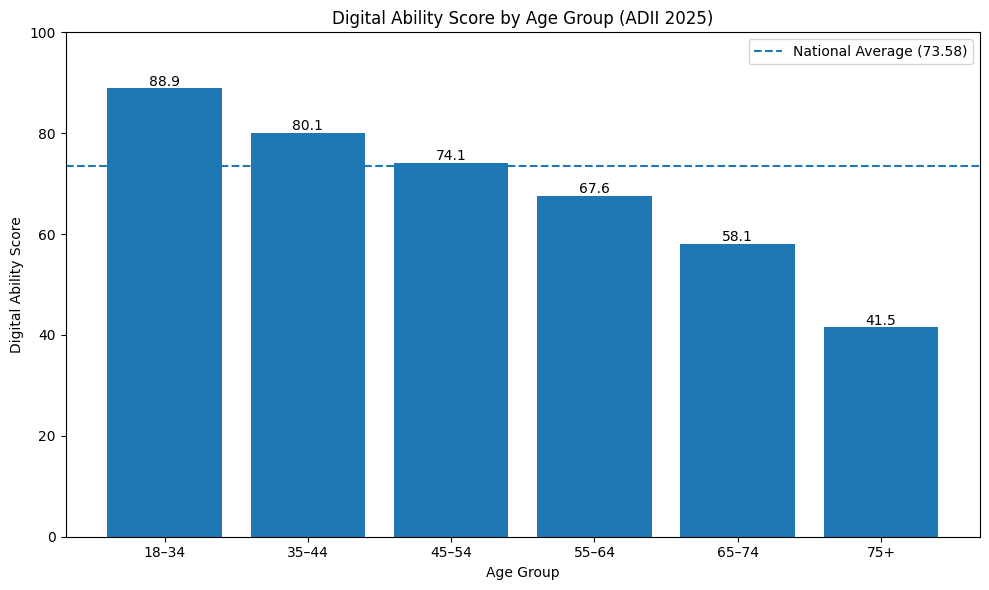

In [62]:
plt.figure(figsize=(10, 6))
bars = plt.bar(
    ability_by_age['Age Group'],
    ability_by_age['Digital Ability Score']
)

plt.axhline(y=national_avg, linestyle='--', label=f'National Average ({national_avg})')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}',
        ha='center'
    )

plt.title('Digital Ability Score by Age Group (ADII 2025)')
plt.xlabel('Age Group')
plt.ylabel('Digital Ability Score')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(output_path, 'digital_ability_by_age.png'), dpi=150, bbox_inches='tight')
plt.show()

### Explaination:-

## Interpretation

The chart shows that digital ability declines as age increases.

Key findings:
- The national average digital ability score is **73.58**
- The **55–64** age group scores **67.59**
- The **65–74** age group scores **58.11**
- The **75+** age group scores **41.52**

This means the target audience for this project is below the national average, especially the 65–74 group. This supports the need for:
- **Epic 1: Digital Services Directory**
- **Epic 2: Step-by-Step How-To Guides**

These features are necessary because older adults may need simpler explanations and more structured guidance to use digital services confidently.

### save chart : digital_ability_by_age

In [63]:
print("Charts saved:")
print(os.listdir(output_path))

Charts saved:
['digital_ability_by_age.png']
